In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import numpy.linalg as lin
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

In [5]:
plt.rcParams["font.family"] = "Arial"

In [6]:
def calcrx1d(pamt,bincrates):
    p=1-(1/365.25)
    sc=np.cumsum(pamt)/np.sum(pamt)
    rx1day = np.interp(p, sc, bincrates)
    return rx1day

In [7]:
def shiftcalc(LRdist,HRdist,bincrates):


    db=(bincrates[2]-bincrates[1])/bincrates[1]  
    # calculate dp/dln(r)
    nb=len(LRdist);
    dpdlnrc= np.concatenate((np.array([0]),LRdist[2:nb]-LRdist[0:(nb-2)],np.array([0])))/(2*db) # centered difference (2nd order accurate; now used near endpoints)
    prm2=LRdist[:(nb-4)]
    prm1=LRdist[1:(nb-3)]
    prp1=LRdist[3:(nb-1)]
    prp2=LRdist[4:]
    dpdlnr= np.concatenate((np.array([0]),np.array([0]),8*(prp1-prm1)-(prp2-prm2),np.array([0]),np.array([0])))/(12*db) # 4th order accurate 
    dpdlnr[1]=dpdlnrc[1] # fill in with second order accurate near endpoints
    dpdlnr[nb-2]=dpdlnrc[nb-2] 

    dt=1
    
    dpamt=HRdist-LRdist
    # calculate the terms in the matrices that will need to be solved
    # (equation 10 in Pendergrass and Hartmann 2014, Two Modes of Change of the Distribution of Rain) 
    # calculate the terms in the matrices that will need to be solved
    # (equation 10 in Pendergrass and Hartmann 2014, Two Modes of Change of the Distribution of Rain) 
    spr2=np.nansum(LRdist**2)
    sdpdlnr2=np.nansum(dpdlnr**2)
    spdpdlnr=np.nansum(LRdist*dpdlnr)
    spdpm=np.nansum(LRdist*dpamt)
    sdpdlnrdpm=np.nansum(dpdlnr*dpamt)
    # set up the matrices
    B=np.array([[0],[-sdpdlnrdpm]])
    A=np.array([[0,-spdpdlnr],[0,sdpdlnr2]])

    try:
        x = np.linalg.solve(A, B)
    except np.linalg.LinAlgError:
        #print("Matrix is singular, using pseudo-inverse.")
        x = np.linalg.pinv(A) @ B
    shift=100*x[1] # shift mode (%)
    pamtshift=-x[1]*dpdlnr+LRdist
    err=100*np.nansum(np.abs(pamtshift[2:]-HRdist[2:]))/np.nansum(np.abs(dpamt[2:]))

    return (shift,pamtshift,err)

# Figure-2: Plotting the rainfall distributions and rx1day values

In [43]:
# AMS standard figure widths in inches
ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.4


width = ams_sizes["two_columns"]
height = width * aspect_ratio
low_res = 25 #100 ## spatial resolution of low res dataset in kilometers
data1= xr.open_dataset('./../data/raindist_data_10_'+str(low_res)+'km.nc') ## Reading in data. Current structure is that the high resolution distribution is available in both input files.
bincrates=data1.precipitation_bin[1:].values ## rain rate bins
## Plotting begins here
res=[10,25,100,200,500,1000]
colrs=['#081d58','#253494','#225ea8','#1d91c0','#41b6c4','#7fcdbb','#c7e9b4','#edf8b1','#ffffd9']
n=0
count=0

otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];
### Now we plot
plt.figure(figsize=(width,height), constrained_layout=True)
plt.clf()

ax=plt.subplot(121)
rx=[]
for i in range(0,len(res)):
    
    if i==0:
        data1= xr.open_dataset('./../data/raindist_data_'+str(res[i])+'_25km.nc')## Reading in data. Current structure is that the high resolution distribution is available in both input files.
        pamt = data1.pamtH[1:].values ## rain amount of HR dataset
        rx1d=calcrx1d(pamt,bincrates)
        rx.append(rx1d)
    else:
        data1= xr.open_dataset('./../data/raindist_data_10_'+str(res[i])+'km.nc')
        pamt= data1.pamtL[1:].values ## rain amount of LR dataset
        rx1d=calcrx1d(pamt,bincrates)
        rx.append(rx1d)
    plt.plot(range(0,len(pamt)),pamt/db, color=colrs[i], label=str(res[i]/100)+'º',linewidth=1.5)
    plt.xlim((4,130))
    plt.ylim((0,1.3))
    legend_properties = {'weight':'bold','size':9}
    plt.legend(prop=legend_properties)

    ### Annotate with the dry day frequency
    ymin, ymax = ax.get_ylim()
    t1=plt.text(115,ymax*0.90, 'a)',fontsize=12)
    #t2=plt.text(4,ymax*0.90, "{:.1f}".format(dryH)+'%',color='m')
    plt.setp(t1,va='top',ha='left')
    #plt.setp(t2,va='top',ha='left')
    plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
    plt.xlabel('Rain rate (mm/d)',fontsize=12,fontweight="bold")
    plt.ylabel('Rain amount (mm/d)',fontsize=12,fontweight="bold")
    plt.xticks(fontsize=10,fontweight="bold")
    plt.yticks(fontsize=10,fontweight="bold")
    for axis in ['top','bottom','left','right']:
        ax.spines[axis].set_linewidth(1.5)
    count+=1
ax2=plt.subplot(122)
rd=pd.DataFrame(rx)
x=['0.1º','0.25º','1º','2º','5º','10º']
plt.bar(x,rx,color=colrs,edgecolor='black', linewidth=2)
plt.xlabel('Spatial Resolution',fontsize=12,fontweight="bold")    
plt.ylabel('RX1day (mm/d)',fontsize=12,fontweight="bold")
plt.xticks(fontsize=10,fontweight="bold")
plt.yticks(fontsize=10,fontweight="bold")
ymin, ymax = ax2.get_ylim()
t2=plt.text(5,ymax*0.90, 'b)',fontsize=12,fontweight='bold')
plt.setp(t2,va='top',ha='right')
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(1.5)

filename='./../figs/fig2_rain_amount.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()

# Figure-3: Joint rain amount distributions distributions

In [44]:
otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 1


width = 10#ams_sizes["more_than_two_columns"]
height = width * aspect_ratio
res=[10,25,100,200,500,1000]
plabel=['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)','m)','n)','o)']
n=1
lr=0
pl=0
fig = plt.figure(figsize=(width, height))
for i in range(0,len(res)):
    lr+=1
    for ii in range(lr,len(res)):

        data3= xr.open_dataset('./../data/rain_jointdist_'+str(res[i])+'_'+str(res[ii])+'km.nc')
        jdL=data3.jdL
        jdH=data3.jdH
        jdF=data3.jdF
        
        
        ax = fig.add_subplot(len(res)-1,len(res)-1,n)
        plt.subplots_adjust(wspace=0.2, hspace=0.4, bottom=0.1, right=0.95, top=0.95)
        levels=np.arange(0.0001,0.001,0.0002)
        cs1=ax.contour(np.arange(0,len(jdH.HR_bin[1:])),np.arange(0,len(jdH.LR_bin[1:])),jdH[1:,1:],linewidths=1.5,colors='#081d58',levels=levels)
        cs2=ax.contour(np.arange(0,len(jdL.HR_bin[1:])),np.arange(0,len(jdL.LR_bin[1:])),jdL[1:,1:],linewidths=1.5,colors='#1d91c0',levels=levels,alpha=0.8)
        plt.xlim((4,130))
        #plt.clabel(cs1, inline=1, fontsize=20)
        #plt.clabel(cs2, inline=1, fontsize=20)
        plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
        plt.setp(ax,yticks=xticks,yticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
        plt.xticks(fontsize=10,fontweight="bold")
        plt.yticks(fontsize=10,fontweight="bold")
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
            np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
        ]
        
        # now plot both limits against eachother
        ax.plot(lims, lims, 'k-', alpha=0.75)
        ax.set_aspect('equal')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(1.5)
        ymin, ymax = ax.get_ylim()
        t1=plt.text(30,ymax*0.95, str(res[i]/100)+'º',fontsize=12,fontweight="bold",color='#081d58')
        t2=plt.text(30,ymax*0.80, str(res[ii]/100)+'º',fontsize=12,fontweight="bold",color='#1d91c0')
        t3=plt.text(5,ymax*0.95, plabel[pl],fontsize=12,fontweight="bold")
        plt.setp(t1,va='top',ha='left')
        plt.setp(t2,va='top',ha='left')
        plt.setp(t3,va='top',ha='left')
        if n in [1,2,3,4,5]:
            t4=plt.text(40,ymax*1.2, 'LR: '+str(res[ii]/100)+'º',fontsize=14,fontweight="bold",color='#1d91c0')
            plt.setp(t4,va='top',ha='left')
        if n in [1,7,13,19,25]:
            plt.xlabel('HR rain rate',fontsize=12,fontweight="bold")
            plt.ylabel('LR rain rate',fontsize=12,fontweight="bold")
        if n in [5,10,15,20,25]:
            t5=plt.text(145,ymax*0.65, 'HR: '+str(res[i]/100)+'º', rotation=270,fontsize=14,fontweight="bold",color='#081d58')
            plt.setp(t5,va='top',ha='left')
        n+=1
        pl=pl+1
        if res[ii]==res[-1]:
            n=n+(i+1)
         

filename='./../figs/fig3_joint_dist.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()
            

# Figure-4: Rain amount differences and shift values

In [45]:
otn=np.linspace(1,9,9)
xtickrates=np.append(0,otn*.1)
xtickrates=np.append(xtickrates,otn)
xtickrates=np.append(xtickrates,otn*10)
xtickrates=np.append(xtickrates,otn*100)
xticks=np.interp(xtickrates,bincrates,range(0,len(bincrates))); #% bin numbers associated with nice number rain rate
xticks,indices=np.unique(xticks,return_index=True)
xtickrates=xtickrates[indices]
### Bin width - needed to normalize the rain amount distribution
db=(bincrates[2]-bincrates[1])/bincrates[1];

ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.6


width = 10#ams_sizes["two_columns"]
height = width * aspect_ratio
res=[10,25,100,200,500]
labels = [f"{r/100:.2f}°" for r in res]
plabel=['a)','b)','c)','d)','e)','f)','g)','h)','i)','j)','k)','l)','m)','n)','o)']
n=1
lr=0
pl=0

fig = plt.figure(figsize=(width, height))
for i in range(0,len(res)):
    for ii in range(i + 1,len(res)):

        data1= xr.open_dataset('./../data/raindist_data_'+str(res[i])+'_'+str(res[ii])+'km.nc')
        pamtH = data1.pamtH[1:].values
        pamtL = data1.pamtL[1:].values
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        db=(bincrates[2]-bincrates[1])/bincrates[1];
        modes = shiftcalc(pamtL,pamtH,bincrates)
        pamtshift = modes[1]
        err=modes[2]

        Po1=(pamtshift)-pamtL ## Difference in rain amount at 0.1º and shifted 1º 
        Po=((pamtH)-(pamtL))

        ### Plotting the difference between HR and LR' combined plot

        ax = fig.add_subplot(len(res)-1,len(res)-1,n)
        plt.subplots_adjust(wspace=0.4, hspace=0.4, bottom=0.1, right=0.95, top=0.95)

        lwidth=2

        plt.axhline(y = 0, color = 'gray')
        plt.plot(range(0,len(Po)),Po/db,color='black',linewidth=1,label=str(res[i]/100)+'º-'+str(res[ii]/100)+'º Difference')
        plt.plot(range(0,len(Po1)),Po1/db,color='steelblue',linewidth=lwidth,label=str(res[i]/100)+'º-'+str(res[ii]/100)+'º Shift')
        
        plt.xlim((4,130))

        #axs[count].text(1,-0.5, "{:.2f}".format(err0)+'%',color='black')
        ymin, ymax = ax.get_ylim()
        plt.text(5,ymax*0.75, plabel[pl]+' '+str(res[i]/100)+'º-'+str(res[ii]/100)+'º',fontsize=10,fontweight="bold")
        #plt.text(10,ymax*0.65,'Shift ('+str(round(shift,2))+'%)',color='steelblue',fontsize=8,fontweight="bold")
        plt.text(10,ymax*0.40,'Error ('+str(round(err,2))+'%)',color='grey',fontsize=10,fontweight="bold")
        #plt.text(120,ymax*0.85,str(round(errs,2))+'%',color='steelblue',fontsize=30,fontweight="bold")
        #plt.text(115,ymax*0.70,str(round(errn,2))+'%',color='orange',fontsize=30,fontweight="bold")
        #plt.text(120,ymax*0.55,str(round(err,2))+'%',color='deeppink',fontsize=30,fontweight="bold")
        plt.setp(ax,xticks=xticks,xticklabels=['0.1','','','','','','','','','1','','','','','','','','','10','','','','','','','','','100','','','','','','','','','1000'])
        plt.xticks(fontsize=10,weight='bold')
        plt.yticks(fontsize=10,weight='bold')
        #plt.legend(fontsize=30,prop={'size': 30,'weight': 'bold'})
        for spine in ax.spines.values():
            spine.set_linewidth(1)
        if n in [1,2,3,4]:
            t4=plt.text(40,ymax*1.4, 'LR: '+str(res[ii]/100)+'º',fontsize=14,fontweight="bold",color='#1d91c0')
            plt.setp(t4,va='top',ha='left')
        if n in [1,6,11,16]:
            plt.xlabel('Rain rate (mm/d)',fontsize=12,weight='bold')
            plt.ylabel('$\mathbf{\mathit{\Delta}}$P (mm/d)',fontsize=12,weight='bold')
            
        if n in [4,8,12,16]:
            t5=plt.text(145,ymax*0.65, 'HR: '+str(res[i]/100)+'º', rotation=270,fontsize=14,fontweight="bold",color='#081d58')
            plt.setp(t5,va='top',ha='left')
        n+=1
        pl=pl+1
        if res[ii]==res[-1]:
            n=n+(i+1)

res=[10,25,100,200,500,1000]
shift_matrix = np.full((len(res), len(res)), np.nan)
for i in range(0,len(res)):
    for ii in range(i + 1,len(res)):
        data1= xr.open_dataset('./../data/raindist_data_'+str(res[i])+'_'+str(res[ii])+'km.nc')
        pamtH = data1.pamtH[1:].values
        pamtL = data1.pamtL[1:].values
        bincrates=data1.precipitation_bin[1:].values ## rain rate bins
        db=(bincrates[2]-bincrates[1])/bincrates[1];
        modes = shiftcalc(pamtL,pamtH,bincrates)
        shift_matrix[i, ii] = modes[0].item()
#modified_matrix = shift_matrix[:, 1:]  # drop first column for x-axis
        
# Add a new axes at bottom left (custom position)
# [left, bottom, width, height] in fraction of figure dimensions (0 to 1)
ax2 = fig.add_axes([-0.02, 0.027, 0.4, 0.4])  # adjust values to fit your layout

sns.heatmap(
    shift_matrix,
    xticklabels=['','0.25º','1º','2º','5º','10º'],
    yticklabels=['0.1º','0.25º','1º','2º','5º',''],  # reverse y-axis to match top-left origin
    cmap='Blues',
    mask=np.tril(np.ones_like(shift_matrix, dtype=bool)),  # mask lower triangle
    annot=True, fmt=".2f",
    annot_kws={"fontsize": 10, "fontweight": "bold"},
    cbar_kws={
        "label": "Shift (%)",
        "orientation": "horizontal",
        "pad": -0.1,
        "shrink": 0.5
    },
    vmin=0, vmax=51,
    square=True
)
# Modify colorbar appearance
cbar = ax2.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.set_label("Shift (%)", fontsize=12, fontweight='bold')

# Manually shift the colorbar to the right
pos = cbar.ax.get_position()
cbar.ax.set_position([pos.x0 + 0.02, pos.y0, pos.width, pos.height])  # shift x0 right by 0.05
cbar.ax.tick_params(labelsize=10)  # font size
for label in cbar.ax.get_xticklabels():  # for horizontal
    label.set_fontweight('bold')

# 2. Set bold colorbar border (outline)
for spine in cbar.ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

ax2.xaxis.tick_top()
ax2.yaxis.tick_right()
ax2.tick_params(
    top=False, labeltop=True,
    bottom=False,
    left=False,
    right=False, labelright=True
)
ax2.set_xlabel('Low Resolution (LR)', fontsize=12, fontweight='bold', labelpad=15)
ax2.xaxis.set_label_position('top')
ax2.set_ylabel('High Resolution (HR)', rotation=270, fontsize=12, fontweight='bold', labelpad=15)
ax2.yaxis.set_label_position('right')
#plt.ylabel('High Resolution (HR)', fontsize=12, fontweight='bold')
plt.setp(ax2.get_xticklabels(), fontsize=10, fontweight='bold')
plt.setp(ax2.get_yticklabels(), rotation=360, fontsize=10, fontweight='bold')
filename='./../figs/fig4_rain_diff.pdf'
plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
plt.close()

<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
/var/folders/0y/zzjz_w1n0pscwp0y_p3q04jr0000gn/T/ipykernel_3027/2714370425.py:81: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$\mathbf{\mathit{\Delta}}$P (mm/d)',fontsize=12,weight='bold')


# Figure-6: Spatial variability of shift, narrowing and their errors

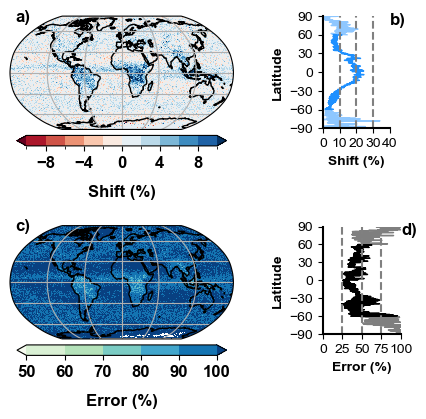

In [15]:
%timeit
sdataN=xr.open_dataset('./../data/shift_10_100km_NH_10v.nc')
sdataS=xr.open_dataset('./../data/shift_10_100km_SH_10v.nc')
sdata=xr.merge([sdataN,sdataS])
zdata=xr.open_dataset('./../data/shift_zonal_10_100km.nc')
sh_trop=zdata['shift'].sel(lat=slice(-60,60));sh_N=zdata['shift'].sel(lat=slice(60,90));sh_S=zdata['shift'].sel(lat=slice(-90,-60))
er_trop=zdata['error'].sel(lat=slice(-60,60));er_N=zdata['error'].sel(lat=slice(60,90));er_S=zdata['error'].sel(lat=slice(-90,-60))
ams_sizes = {
    "one_column": 3.2,
    "two_thirds": 4.5,
    "two_columns": 5.5,
    "more_than_two_columns": 6.5,
}

# Common aspect ratio: width : height = 4:3 → height = width * 0.75
# You can change this based on the visual needs of your plot
aspect_ratio = 0.65


width = ams_sizes["more_than_two_columns"]
height = width * aspect_ratio

# Extract lat, lon, and data (ensure it's 2D)
levels=np.arange(-10,12,2)
cmap = plt.get_cmap('RdBu', len(levels)+1)  # Discretize the colormap
norm = BoundaryNorm(boundaries=levels, ncolors=cmap.N, extend='both')

# Plot
fig = plt.figure(figsize=(width, height))
plt.subplots_adjust(wspace=0.4, hspace=0.4, bottom=0.1, right=0.95, top=0.95)

lon, lat = np.meshgrid(sdata['lon'], sdata['lat'])
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.Robinson())
pcm1 = ax1.pcolormesh(
    lon, lat, sdata['shift'].T,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading='auto'
)
pcm1.set_rasterized(True)

ax1.coastlines()
ax1.gridlines()
ymin, ymax = ax1.get_ylim()
xmin, xmax = ax1.get_xlim()
plt.text(0.95*xmin,0.90*ymax,'a)',fontsize=12,fontweight='bold')

cbar = fig.colorbar(pcm1, ax=ax1, orientation='horizontal', label='Shift (%)',fraction=0.07, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # font size of tick labels
for tick_label in cbar.ax.get_xticklabels():  # use get_yticklabels() for vertical bar
    tick_label.set_fontweight('bold')
cbar.set_label("Shift (%)", fontsize=12, fontweight='bold', labelpad=10)

## Zonal shift 
ax2=fig.add_subplot(2,2,2)
ax2.plot(sh_trop,sh_trop['lat'],'dodgerblue',linewidth=1)
ax2.plot(sh_N,sh_N['lat'],'dodgerblue',linewidth=1,alpha=0.5)
ax2.plot(sh_S,sh_S['lat'],'dodgerblue',linewidth=1,alpha=0.5)
ax2.spines[['right', 'top']].set_visible(False)
ax2.spines[['left', 'bottom']].set_linewidth(1.5)
lat_labels= [-90,-60,-30,0,30,60,90]
#ax2.set_yticks(np.sin(np.deg2rad(lat_labels)),lat_labels)
ax2.set_yticks(lat_labels)
ax2.set_xticks([0,10,20,30,40])
ax2.set_xlim([0,40])
ax2.set_ylim([-90,90])
ax2.vlines([10,20,30],ymin = -90, ymax = 90,linestyles='dashed',linewidth=1.5, color='grey')
ax2.set_xlabel('Shift (%)',fontsize=10,fontweight='bold')
ax2.set_ylabel('Latitude',fontsize=10,fontweight='bold')
chartBox = ax2.get_position() 
ax2.set_position([chartBox.x0,  
                  chartBox.y0*1.07, 
                  chartBox.width * 0.3, 
                  chartBox.height*0.75])
ymin, ymax = ax2.get_ylim()
xmin, xmax = ax2.get_xlim()
plt.text(40,0.85*ymax,'b)',fontsize=12,fontweight='bold')


# Spatial distribution of Error
levels=np.arange(50,110,10)
cmap = plt.get_cmap('GnBu', len(levels)+1)  # Discretize the colormap
norm = BoundaryNorm(boundaries=levels, ncolors=cmap.N, extend='both')

ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Robinson())
pcm2 = ax3.pcolormesh(
    lon, lat, sdata['error'].T,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm,
    shading='auto'
)
pcm2.set_rasterized(True)

ax3.coastlines()
ax3.gridlines()
ymin, ymax = ax3.get_ylim()
xmin, xmax = ax3.get_xlim()
plt.text(0.95*xmin,0.90*ymax,'c)',fontsize=12,fontweight='bold')

cbar = fig.colorbar(pcm2, ax=ax3, orientation='horizontal', label='Error (%)',fraction=0.07, pad=0.04)
cbar.ax.tick_params(labelsize=12)  # font size of tick labels
for tick_label in cbar.ax.get_xticklabels():  # use get_yticklabels() for vertical bar
    tick_label.set_fontweight('bold')
cbar.set_label("Error (%)", fontsize=12, fontweight='bold', labelpad=10)

# Zonal plot of error
ax4=fig.add_subplot(2,2,4)
ax4.plot(er_trop,er_trop['lat'],'black',linewidth=1)
ax4.plot(er_N,er_N['lat'],'black',linewidth=1,alpha=0.5)
ax4.plot(er_S,er_S['lat'],'black',linewidth=1,alpha=0.5)
ax4.spines[['right', 'top']].set_visible(False)
ax4.spines[['left', 'bottom']].set_linewidth(1.5)
lat_labels= [-90,-60,-30,0,30,60,90]
#ax2.set_yticks(np.sin(np.deg2rad(lat_labels)),lat_labels)
ax4.set_yticks(lat_labels)
ax4.set_xticks([0,25,50,75,100])
ax4.set_xlim([0,100])
ax4.set_ylim([-90,90])
ax4.vlines([25,50,75],ymin = -90, ymax = 90,linestyles='dashed',linewidth=1.5, color='grey')
ax4.set_xlabel('Error (%)',fontsize=10,fontweight='bold')
ax4.set_ylabel('Latitude',fontsize=10,fontweight='bold')
chartBox = ax4.get_position() 
ax4.set_position([chartBox.x0,  
                  chartBox.y0*1.5, 
                  chartBox.width * 0.35, 
                  chartBox.height*0.72])
ymin, ymax = ax4.get_ylim()
xmin, xmax = ax4.get_xlim()
plt.text(100,0.85*ymax,'d)',fontsize=12,fontweight='bold')

filename='./../figs/fig6_spatial.pdf'
#plt.savefig(filename, format="pdf", bbox_inches="tight",dpi=300)
#plt.close()